# Analysis of a Switching Poisson System

This notebook simulates and analyzes a neural population whose internal dynamics **switch** between two distinct behaviors (Regimes).

### 1. Discrete State Switching (Markov Chain)
The system switches between two discrete regimes, $s_t \in \{0, 1\}$, where $0 = \text{Rotation (A)}$ and $1 = \text{Decay (B)}$.

$$P(s_t = j \mid s_{t-1} = i) = T_{ij}$$

Where the transition matrix $T$ is:
$$
T = \begin{bmatrix}
0.98 & 0.02 \\
0.01 & 0.99 
\end{bmatrix}
$$

* **Rotation (A):** Lasts ~50 steps on average ($p_{ab} = 0.02$).
* **Decay (B):** Lasts ~100 steps on average ($p_{ba} = 0.01$).

---

### 2. Continuous Latent Dynamics
The continuous latent state $z_t \in \mathbb{R}^2$ evolves according to the active discrete regime $s_t$:

$$z_t = F_{s_t} z_{t-1} + \epsilon_t, \quad \epsilon_t \sim \mathcal{N}(0, Q)$$

Where the dynamics matrices are:
* **If $s_t = 0$ (Rotation):** $F_0$ is a rotation matrix with angle $\theta = \pi/40$.
* **If $s_t = 1$ (Decay):** $F_1 = 0.98 \cdot I$ (Identity matrix scaled by 0.98).
* **Process Noise:** $Q = 0.001 \cdot I$.

---

### 3. Observation Model (Poisson Emissions)
The observed spike counts $y_t \in \mathbb{N}^6$ (for 6 neurons) are generated from the latent state $z_t$ via a Poisson distribution with a softplus link function.

$$y_t \sim \text{Poisson}(\lambda_t)$$

The rate parameter $\lambda_t$ is defined as:

$$\lambda_t = \text{softplus}(C z_t + d_{s_t})$$

* $C \in \mathbb{R}^{6 \times 2}$ is the emission weights matrix (`emission_matrix`).
* $d_{s_t}$ is the **State-Dependent Bias**:
    * **State A (Rotation):** $d=4.0$ (High Firing Rate)
    * **State B (Decay):** $d=-2.0$ (Near Silence)
* $\text{softplus}(x) = \log(1 + e^x)$.

## 4. Inferring Latent States from Spikes

The goal is to recover the continuous latent trajectory $z_t$ given only the observed spike counts $y_t$.

### The Challenge
The true system is a **Switching Linear Dynamical System (SLDS)**: it jumps between "Rotation" and "Decay" modes. Exact inference in SLDS is computationally intractable because the number of possible discrete state histories grows exponentially ($2^T$).

### The Solution: Continuous Approximation via EKF
Instead of modeling the switching explicitly during inference, we approximate the system using a single, flexible **Generalized Gaussian State Space Model (GGSSM)**.

We employ the **Extended Kalman Smoother (CMGS)** with a specific heuristic:
1.  **Damped Random Walk:** We set the inference dynamics to $z_{t+1} = 0.96 z_t + \epsilon$. This assumes the state generally stays near zero but has no strong directional preference (unlike the rotation).
2.  **Inflated Noise:** We set the process noise covariance $Q \approx 0.1 \cdot I$ (much higher than the true $0.001$). This tells the filter to trust the observations more than the dynamics, allowing it to "catch up" quickly when the true system switches regimes.

**The Algorithm (CMGS):**
The *Conditional Moments Gaussian Smoother* iteratively updates the mean $\mu_t$ and covariance $\Sigma_t$ of the latent state by linearizing the Poisson emission function:

$$
\begin{align*}
\text{Prediction:} & \quad \mu_{t|t-1} = F \mu_{t-1} \\
\text{Update:} & \quad \mu_{t|t} = \mu_{t|t-1} + K_t (y_t - \mathbb{E}[y_t])
\end{align*}
$$

---
### Understanding the Latent State ($z_1, z_2$)

The continuous latent state is a 2-dimensional vector $z_t = [z_{1,t}, z_{2,t}]$. Even though the system has two distinct behaviors (Rotation vs. Decay), we use the **same two variables** to track the state at all times. Their interpretation changes depending on the active regime:

#### 1. In State A: Rotation (The "Phase" Engine)
When the system is in the **Rotation** state, $z_1$ and $z_2$ act as **coupled coordinates** (like $x$ and $y$ on a unit circle).
* They push and pull on each other mathematically to create oscillation.
* You need both variables to define the current **Phase** (angle) of the cycle.
* $z_1$ creates the "Cosine" wave, while $z_2$ creates the "Sine" wave.

#### 2. In State B: Decay (The "Amplitude" Sink)
When the system switches to **Decay**, the coupling stops. $z_1$ and $z_2$ become **independent amplitude trackers**.
* Both variables are simply multiplied by a decay factor (e.g., $0.98$) at every step.
* They represent the fading **strength** of the previous activity as it relaxes toward zero.
* **Note on Drift:** During long decay periods, you will see the values wiggle or drift away from zero. This is a **Random Walk** effect caused by the process noise (`dynamics_cov`) constantly "kicking" the state even while the decay tries to pull it to the center.

#### Why not use different variables?
We use the same vector $z$ for both states to ensure **Continuity**. When the brain switches from *Rotating* to *Decaying*, the decay process picks up exactly where the rotation left off (e.g., stopping a spinning wheel with your hand), rather than teleporting to a new value.


In [36]:
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
from jax import vmap, lax
from tensorflow_probability.substrates.jax.distributions import Poisson
from jax.nn import softplus

# Dynamax Imports
from dynamax.generalized_gaussian_ssm import ParamsGGSSM, GeneralizedGaussianSSM, EKFIntegrals
from dynamax.generalized_gaussian_ssm import conditional_moments_gaussian_smoother as cmgs
from dynamax.utils.utils import random_rotation

# --- Global Configuration ---
state_dim = 2       # 2D Latent Space
emission_dim = 6    # 6 Observed Neurons
num_timesteps = 1000 # Long duration to see multiple switches
num_trials = 3      # Number of independent trials to simulate

## 1. Defining the "True" Switching Physics
We define two very different dynamics matrices: one that rotates and one that decays. We also define a "sticky" transition matrix so the system stays in each state for ~50-100 steps.

In [37]:
# A. Discrete Transition Matrix (Switching Probabilities)
p_ab = 0.02  # Prob of switching A -> B (Avg duration 50 steps)
p_ba = 0.01  # Prob of switching B -> A (Avg duration 100 steps)

transition_matrix = jnp.array([
    [1.0 - p_ab, p_ab],  # Row 0: From A
    [p_ba, 1.0 - p_ba]   # Row 1: From B
])

# B. Continuous Dynamics (The 2 Regimes)
# State A (0): Rotates slowly (theta = pi/40)
F_A = random_rotation(jr.PRNGKey(0), state_dim, theta=jnp.pi/40)

# State B (1): Decays (Shrinks towards zero)
# Note: We use 0.98 (slow decay) so the signal doesn't vanish completely during long stops.
F_B = jnp.eye(state_dim) * 0.98

# Stack them for easy selection: F[0] or F[1]
dynamics_matrices = jnp.stack([F_A, F_B])
dynamics_cov = 0.001 * jnp.eye(state_dim) # Low noise for smooth trajectories

# C. Emission Model (Latent -> Spikes)
emission_matrix = jr.normal(jr.PRNGKey(1), shape=(emission_dim, state_dim))

# Define biases for each state
# State A (Rotation): High baseline firing (4.0)
# State B (Decay): Low baseline firing (-2.0) -> effectively silence
biases = jnp.stack([
    jnp.ones(emission_dim) * 4.0,  # Bias for State 0
    jnp.ones(emission_dim) * -2.0  # Bias for State 1
])

# Updated Emission Function takes State (s) as input
def emission_mean_fn(z, s):
    # Select bias based on current discrete state 's'
    b = biases[s] 
    return softplus(jnp.dot(emission_matrix, z) + b)

## 2. Simulation Loop
We use `jax.lax.scan` to implement the custom logic where the discrete state $s_t$ selects the dynamics matrix $F_{s_t}$ at every step.

Simulating Switching Poisson Model...


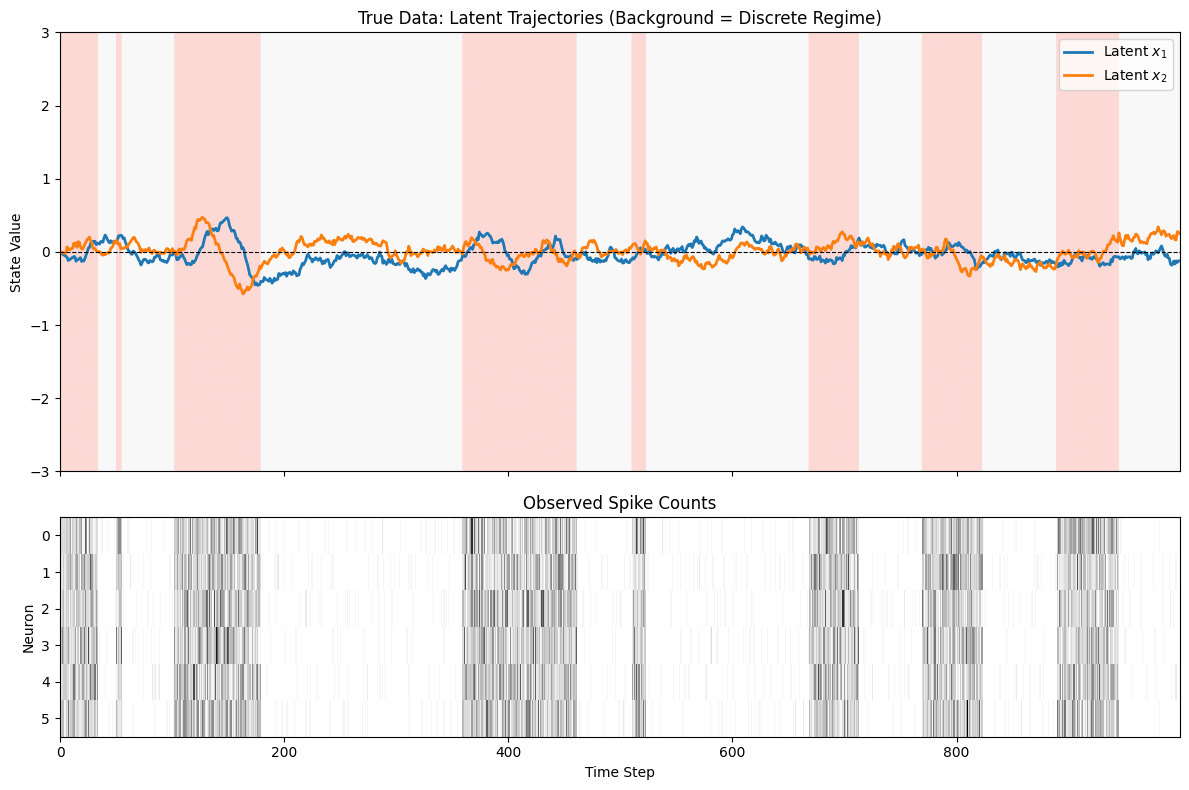

In [38]:
def sample_switching_slds(key, num_steps):
    k1, k2, k3 = jr.split(key, 3)
    
    # Initial conditions
    z0 = jnp.zeros(state_dim)
    s0 = 0 # Start in State A (Rotating)
    
    def step_fn(carry, key):
        z_prev, s_prev = carry
        k_trans, k_dyn, k_obs = jr.split(key, 3)
        
        # 1. Discrete Step: Switch State? (Markov Chain)
        probs = transition_matrix[s_prev]
        s_next = jr.categorical(k_trans, jnp.log(probs))
        
        # 2. Continuous Step: Evolve z using the chosen dynamics matrix
        F = dynamics_matrices[s_next]
        mean_next = F @ z_prev
        z_next = jr.multivariate_normal(k_dyn, mean_next, dynamics_cov)
        
        # 3. Emission Step: Generate Poisson Spikes
        # UPDATED: Pass state s_next to select the correct bias
        rate = emission_mean_fn(z_next, s_next)
        y_next = Poisson(rate).sample(seed=k_obs)
        
        return (z_next, s_next), (z_next, s_next, y_next)

    # Run the loop
    keys = jr.split(k2, num_steps)
    _, (latents, states, spikes) = lax.scan(step_fn, (z0, s0), keys)
    return states, latents, spikes

# Run Simulation (Vectorized over trials)
print("Simulating Switching Poisson Model...")
batch_states, batch_latents, batch_spikes = vmap(
    lambda k: sample_switching_slds(k, num_timesteps)
)(jr.split(jr.PRNGKey(42), num_trials))

# Visualization Helper
def plot_switching_data(latents, discrete_states, emissions, title="True Data"):
    latent_dim = latents.shape[-1]
    emissions_dim = emissions.shape[-1]
    num_timesteps = emissions.shape[0]

    fig, axs = plt.subplots(2, 1, height_ratios=(1, 0.5), figsize=(12, 8), sharex=True)
    
    # Top: Latents + Regimes
    ax = axs[0]
    # Background color = Discrete State
    ax.imshow(discrete_states[None, :], aspect='auto', cmap="Pastel1", 
              extent=[0, num_timesteps, -3, 3], alpha=0.5)
    
    # Lines = Continuous States
    for d in range(latent_dim):
        ax.plot(latents[:, d], lw=2, label=f"Latent $x_{d+1}$")
    
    ax.set_title(f"{title}: Latent Trajectories (Background = Discrete Regime)")
    ax.legend(loc="upper right")
    ax.set_ylabel("State Value")
    ax.axhline(0,c='k',lw=.8, ls='--')

    # Bottom: Spikes
    ax = axs[1]
    ax.imshow(emissions.T, aspect="auto", interpolation="nearest", cmap="Greys")
    ax.set_ylabel("Neuron")
    ax.set_xlabel("Time Step")
    ax.set_title("Observed Spike Counts")
    
    plt.tight_layout()
    plt.show()

# Plot first trial
plot_switching_data(batch_latents[0], batch_states[0], batch_spikes[0])

## 3. Inference via Approximation
Since the data switches between dynamics, a single linear model cannot fit it perfectly. However, we can approximate the system using a **Generalized Gaussian SSM** with "Damped Random Walk" dynamics.

**Key Strategy:**
1.  **Dynamics:** Use `0.96 * z` (Damping). This keeps the state centered but allows it to follow the data.
2.  **Noise:** Use relatively high covariance `0.1` (vs true `0.001`). This makes the filter flexible enough to "catch up" when the physics changes unexpectedly.
3.  **Emission Assumption:** Since the filter doesn't know the discrete state, we assume the "Active" bias (4.0) for inference. This allows it to capture the rotational structure well, while treating the silence of the Decay state as simply a lack of observations.

In [39]:
# 1. Define the Inference Model
inference_model = GeneralizedGaussianSSM(state_dim, emission_dim)

# 2. Define Parameters for Approximation

# We define a simplified emission function for inference that assumes the "Active" state bias
def inference_emission_fn(z):
    # Use the high bias (4.0) so the filter expects data when z is active
    return softplus(jnp.dot(emission_matrix, z) + 4.0)

inference_params = ParamsGGSSM(
    initial_mean=jnp.zeros(state_dim),
    initial_covariance=jnp.eye(state_dim),
    
    # Damped Identity = "Stay near zero, but drift is allowed"
    # CHANGE 1: Use 0.99 (or 1.0) instead of 0.70.
    # This creates a "Random Walk". It doesn't force decay; it just lets the state "be".
    dynamics_function=lambda z: 0.99 * z, 
    
    # CHANGE 2: Increase covariance to 0.1 (or even 0.5).
    # This tells the filter: "My movement rule is weak, trust the spikes more."
    dynamics_covariance=0.4 * jnp.eye(state_dim),
    
    emission_mean_function=inference_emission_fn,
    emission_cov_function=lambda z: jnp.diag(inference_emission_fn(z))
)

# 3. Run Inference (EKF Smoother)
print("Running Inference...")
posts = vmap(lambda y: cmgs(
    inference_params, EKFIntegrals(), y
))(batch_spikes)

print("Inference Complete.")

Running Inference...
Inference Complete.


## 4. Recovering Discrete States (The Physics Test)
Now that we have the estimated trajectory $\hat{z}_t$, we can reverse-engineer the switching.

**Logic:** At every step, we check:
* Did the state rotate? (Consistent with Matrix A?)
* Did the state decay? (Consistent with Matrix B?)

The matrix with the smaller prediction error is the likely regime.


### Why do we provide $F_A$ and $F_B$ to the recovery function?

You might wonder: *"If we use the true dynamics matrices $F_A$ and $F_B$, isn't that cheating?"*

**The answer is No.** This step represents a **Classification** task, not a **Learning** task.

In this context, we act like a doctor diagnosing a patient:
* **The Data (Spikes):** The patient's symptoms.
* **The Inferred State ($z$):** The patient's internal condition (derived from symptoms).
* **The Matrices ($F_A, F_B$):** The medical textbook definitions of "The Flu" ($A$) vs "A Cold" ($B$).

We already "know" the physics of the brain states (the textbook). The challenge is to look at the noisy, ambiguous spike train and determine **which of the known physics rules is currently active.**

**Input Breakdown:**
1.  `smoothed_means`: The **estimated** trajectory derived *only* from the spikes (the patient's data).
2.  `F_A, F_B`: The **known** candidate models (the textbook definitions).

The function simply checks: *"Does the recovered trajectory look more like a Rotation or a Decay right now?"*

## 5. Going Further: Unsupervised Learning (Blind Discovery)

In this notebook, we performed **Supervised Inference**. We provided the recovery algorithm with the "answer key"—the true dynamics matrices $F_A$ and $F_B$. We essentially asked: *"Which of these two known physics rules explains the data best right now?"*

But what if we didn't know the rules? What if we just had the spike train and wanted to discover that there are two states, and what those states do?

### The "Chicken and Egg" Problem
This is known as **Unsupervised Learning** or **System Identification**. It is difficult because:
1.  To know the **Dynamics** ($F_A, F_B$), we need to know the **States** ($s_t, z_t$) to train on.
2.  To infer the **States**, we need to know the **Dynamics** to filter the noise.

### The Solution: Expectation-Maximization (EM)
To solve this, we use an iterative algorithm that alternates between two steps until it converges:

1.  **E-Step (Estimation):** Freeze the parameters ($F, Q, C$). Run the filter/smoother to guess the best latent trajectory $z_t$ and discrete states $s_t$.
2.  **M-Step (Maximization):** Freeze the estimated states. Use linear regression to find the best matrices $F_A$ and $F_B$ that would have produced those states.

By repeating this loop, the model gradually "discovers" the rotation and decay dynamics purely from the spike patterns, without ever being told they exist.

F_A: [[ 0.9969173   0.07845906]
 [-0.07845912  0.99691725]] F_B: [[0.98 0.  ]
 [0.   0.98]]
State Recovery Accuracy: 70.40%


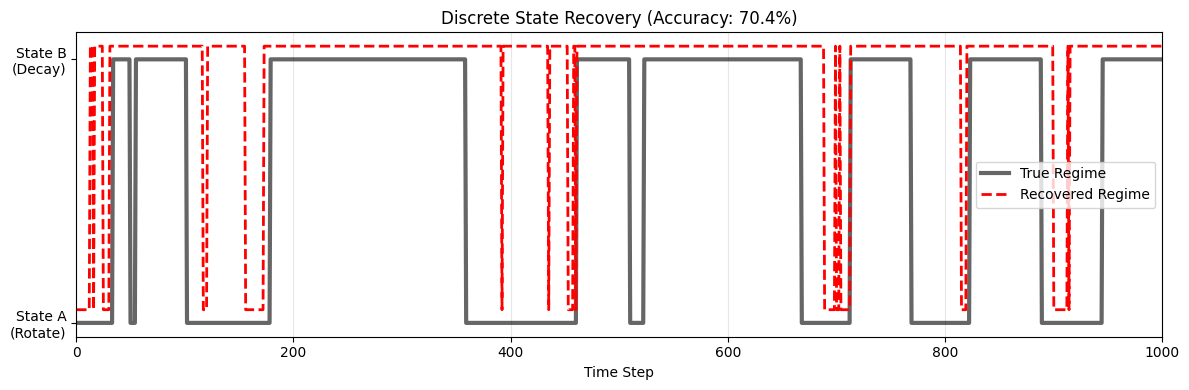

In [44]:
def recover_discrete_states_smoothed(smoothed_means, F_A, F_B, window=5):
    """
    Infers state by comparing prediction errors over a sliding window.
    This removes flickering caused by momentary noise.
    """
    T = smoothed_means.shape[0]
    inferred_states = []
    
    # Pre-calculate errors for all steps
    errors_A = []
    errors_B = []
    
    for t in range(1, T):
        x_prev = smoothed_means[t-1]
        x_curr = smoothed_means[t]
        
        # Error for Rotation
        pred_A = F_A @ x_prev
        err_A = jnp.sum((x_curr - pred_A)**2)
        
        # Error for Decay
        pred_B = F_B @ x_prev
        err_B = jnp.sum((x_curr - pred_B)**2)
        
        errors_A.append(err_A)
        errors_B.append(err_B)
        
    errors_A = jnp.array(errors_A)
    errors_B = jnp.array(errors_B)
    
    # Smooth the errors using a simple moving average (voting)
    # We define a simple boxcar kernel
    kernel = jnp.ones(window) / window
    
    # Convolve errors to smooth them
    smooth_A = jnp.convolve(errors_A, kernel, mode='same')
    smooth_B = jnp.convolve(errors_B, kernel, mode='same')
    
    # Classify based on SMOOTHED errors
    # 0 = Rotation (A), 1 = Decay (B)
    # If Error A < Error B, it's Rotation.
    inferred_states = jnp.where(smooth_A < smooth_B, 0, 1)
    
    # Pad the first step (lost due to t-1)
    inferred_states = jnp.concatenate([jnp.array([0]), inferred_states])
            
    return inferred_states
    
# Run Recovery on Trial 0
trial_idx = 0
inferred_seq = recover_discrete_states_smoothed(posts.smoothed_means[trial_idx], F_A, F_B, window=20)
true_seq = batch_states[trial_idx]

print('F_A:',F_A,'F_B:',F_B)
# Calculate Accuracy
accuracy = jnp.mean(inferred_seq == true_seq) * 100
print(f"State Recovery Accuracy: {accuracy:.2f}%")

# --- Final Plot: Truth vs Recovery ---
fig, ax = plt.subplots(figsize=(12, 4))

# Plot True State (Black Line)
ax.plot(true_seq, 'k-', linewidth=3, label='True Regime', alpha=0.6)

# Plot Recovered State (Red Dashed)
# Shift slightly (+0.05) to make overlaps visible
ax.plot(inferred_seq + 0.05, 'r--', linewidth=2, label='Recovered Regime')

ax.set_yticks([0, 1])
ax.set_yticklabels(['State A\n(Rotate)', 'State B\n(Decay)'])
ax.set_xlabel("Time Step")
ax.set_title(f"Discrete State Recovery (Accuracy: {accuracy:.1f}%)")
ax.legend(loc="center right")
ax.set_xlim(0, num_timesteps)
ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.show()